# 🎙️ Task 2: Emotion Recognition from Speech
**CodeAlpha Machine Learning Internship**

Recognize human emotions from speech audio using Deep CNN + MFCC features.

> ✅ **Runtime:** Runtime → Change runtime type → **GPU** (recommended)
>
> **Dataset:** If you have RAVDESS, upload the zip in the cell below. Otherwise the script runs in **demo mode** automatically.

In [1]:
# ── Install Libraries ────────────────────────
!pip install -q librosa tensorflow numpy pandas matplotlib seaborn
print("✅ Libraries installed!")

✅ Libraries installed!


In [2]:
# ── Imports ───────────────────────────────────
import os, glob, warnings, zipfile
warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import librosa

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, Conv1D, MaxPooling1D, Dense, Dropout,
                                      BatchNormalization, GlobalAveragePooling1D)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical

print(f"✅ TensorFlow: {tf.__version__}")
print(f"✅ GPU: {len(tf.config.list_physical_devices('GPU'))>0}")

✅ TensorFlow: 2.20.0
✅ GPU: True


In [3]:
# ── Upload RAVDESS (Optional) ─────────────────
# Agar RAVDESS hai to yahan upload karo (zip file)
# Agar nahi hai to skip karo — demo mode chal jaega

RAVDESS_PATH = "./RAVDESS"
USE_REAL_DATA = False

try:
    from google.colab import files
    print("RAVDESS zip upload karo (ya Ctrl+C skip ke liye)...")
    uploaded = files.upload()
    for fname in uploaded.keys():
        if fname.endswith('.zip'):
            with zipfile.ZipFile(fname, 'r') as z:
                z.extractall(".")
            # Find extracted folder
            for d in os.listdir('.'):
                if os.path.isdir(d) and 'actor' in d.lower():
                    RAVDESS_PATH = "."
                    break
            USE_REAL_DATA = True
            print(f"✅ RAVDESS extracted!")
except (KeyboardInterrupt, Exception):
    print("⚠️  Skip — Demo mode chalega (synthetic data)")

RAVDESS zip upload karo (ya Ctrl+C skip ke liye)...


Saving kaggle.json to kaggle.json


In [4]:
# ── Configuration ────────────────────────────
SAMPLE_RATE = 22050
DURATION    = 3
N_MFCC      = 40
BATCH_SIZE  = 32
EPOCHS      = 50

EMOTIONS = {
    '01':'neutral','02':'calm','03':'happy','04':'sad',
    '05':'angry','06':'fearful','07':'disgust','08':'surprised'
}

# ── Feature Extraction ────────────────────────
def extract_features(file_path):
    try:
        audio, sr = librosa.load(file_path, sr=SAMPLE_RATE, duration=DURATION, mono=True)
        tlen = SAMPLE_RATE * DURATION
        audio = np.pad(audio,(0,max(0,tlen-len(audio))))[:tlen]

        feats = []
        mfcc = librosa.feature.mfcc(y=audio,sr=sr,n_mfcc=N_MFCC)
        feats += list(np.mean(mfcc,axis=1)) + list(np.std(mfcc,axis=1))
        chroma = librosa.feature.chroma_stft(y=audio,sr=sr)
        feats += list(np.mean(chroma,axis=1)) + list(np.std(chroma,axis=1))
        mel = librosa.power_to_db(librosa.feature.melspectrogram(y=audio,sr=sr))
        feats += list(np.mean(mel,axis=1)) + list(np.std(mel,axis=1))
        contrast = librosa.feature.spectral_contrast(y=audio,sr=sr)
        feats += list(np.mean(contrast,axis=1)) + list(np.std(contrast,axis=1))
        tonnetz = librosa.feature.tonnetz(y=librosa.effects.harmonic(audio),sr=sr)
        feats += list(np.mean(tonnetz,axis=1)) + list(np.std(tonnetz,axis=1))
        return np.array(feats)
    except:
        return None

def load_ravdess(path):
    X, y = [], []
    wavs = glob.glob(os.path.join(path,'**','*.wav'),recursive=True)
    print(f"  Found {len(wavs)} files")
    for i,f in enumerate(wavs):
        if (i+1)%100==0: print(f"  Processing {i+1}/{len(wavs)}")
        parts = os.path.basename(f).split('-')
        if len(parts)<3 or parts[2] not in EMOTIONS: continue
        feat = extract_features(f)
        if feat is not None:
            X.append(feat); y.append(EMOTIONS[parts[2]])
    return np.array(X), np.array(y)

def demo_data(n=1440, nf=386):
    print("  ⚠️ Synthetic demo data use ho raha hai")
    emos = list(EMOTIONS.values()); npc = n//len(emos)
    X,y = [],[]
    for i,e in enumerate(emos):
        m = np.random.randn(nf)*2 + i*0.5
        X.append(np.random.randn(npc,nf)+m); y+=[e]*npc
    return np.vstack(X), np.array(y)

print("Loading data...")
if USE_REAL_DATA and os.path.exists(RAVDESS_PATH):
    X, y = load_ravdess(RAVDESS_PATH)
else:
    X, y = demo_data()

print(f"✅ X shape: {X.shape}")
for e,c in zip(*np.unique(y,return_counts=True)):
    print(f"  {e:<12}: {c}")

Loading data...
  ⚠️ Synthetic demo data use ho raha hai
✅ X shape: (1440, 386)
  angry       : 180
  calm        : 180
  disgust     : 180
  fearful     : 180
  happy       : 180
  neutral     : 180
  sad         : 180
  surprised   : 180


In [5]:
# ── Preprocessing ────────────────────────────
from sklearn.preprocessing import StandardScaler

le = LabelEncoder()
y_enc = le.fit_transform(y)
n_classes = len(le.classes_)
y_cat = to_categorical(y_enc, n_classes)

X_scaled = StandardScaler().fit_transform(X).reshape(X.shape[0],X.shape[1],1)

X_tr, X_te, y_tr, y_te = train_test_split(X_scaled,y_cat,test_size=0.2,random_state=42,stratify=y_enc)
X_tr, X_va, y_tr, y_va = train_test_split(X_tr,y_tr,test_size=0.15,random_state=42,
                                           stratify=np.argmax(y_tr,axis=1))
print(f"✅ Train:{X_tr.shape[0]} | Val:{X_va.shape[0]} | Test:{X_te.shape[0]}")

✅ Train:979 | Val:173 | Test:288


In [6]:
# ── Build & Train CNN ────────────────────────
inp = Input(shape=(X_tr.shape[1],1))
x = Conv1D(128,5,padding='same',activation='relu')(inp)
x = BatchNormalization()(x); x = Conv1D(128,5,padding='same',activation='relu')(x)
x = BatchNormalization()(x); x = MaxPooling1D(2)(x); x = Dropout(0.3)(x)
x = Conv1D(256,3,padding='same',activation='relu')(x)
x = BatchNormalization()(x); x = Conv1D(256,3,padding='same',activation='relu')(x)
x = BatchNormalization()(x); x = MaxPooling1D(2)(x); x = Dropout(0.35)(x)
x = Conv1D(128,3,padding='same',activation='relu')(x)
x = BatchNormalization()(x); x = GlobalAveragePooling1D()(x); x = Dropout(0.4)(x)
x = Dense(256,activation='relu')(x); x = BatchNormalization()(x); x = Dropout(0.4)(x)
x = Dense(128,activation='relu')(x); x = Dropout(0.3)(x)
out = Dense(n_classes,activation='softmax')(x)

model = Model(inp,out)
model.compile(optimizer=Adam(3e-4),loss='categorical_crossentropy',metrics=['accuracy'])
model.summary()

history = model.fit(X_tr,y_tr, validation_data=(X_va,y_va),
    batch_size=BATCH_SIZE, epochs=EPOCHS,
    callbacks=[EarlyStopping(monitor='val_accuracy',patience=15,restore_best_weights=True),
               ReduceLROnPlateau(factor=0.5,patience=7,min_lr=1e-6)],
    verbose=1)

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 386, 1)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 386, 128)       │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 386, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 386, 128)       │        82,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 386, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 193, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 193, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 193, 256)       │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 193, 256)       │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 193, 256)       │       196,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 193, 256)       │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 96, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 96, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 96, 128)        │        98,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 96, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 548,232 (2.09 MB)

 Trainable params: 545,928 (2.08 MB)

 Non-trainable params: 2,304 (9.00 KB)

Epoch 1/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 27s 340ms/step - accuracy: 0.3953 - loss: 1.7162 - val_accuracy: 0.1214 - val_loss: 2.0657 - learning_rate: 3.0000e-04
Epoch 2/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5884 - loss: 0.9982 - val_accuracy: 0.1214 - val_loss: 2.1532 - learning_rate: 3.0000e-04
Epoch 3/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7038 - loss: 0.7491 - val_accuracy: 0.1214 - val_loss: 2.3474 - learning_rate: 3.0000e-04
Epoch 4/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8151 - loss: 0.4719 - val_accuracy: 0.1214 - val_loss: 2.6796 - learning_rate: 3.0000e-04
Epoch 5/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8570 - loss: 0.4016 - val_accuracy: 0.1214 - val_loss: 2.6750 - learning_rate: 3.0000e-04
Epoch 6/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9173 - loss: 0.2664 - val_accuracy: 0.1329 - val_loss: 3.0817 - learning_rate: 3.0000e-04
Epoch 7/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.906

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step  


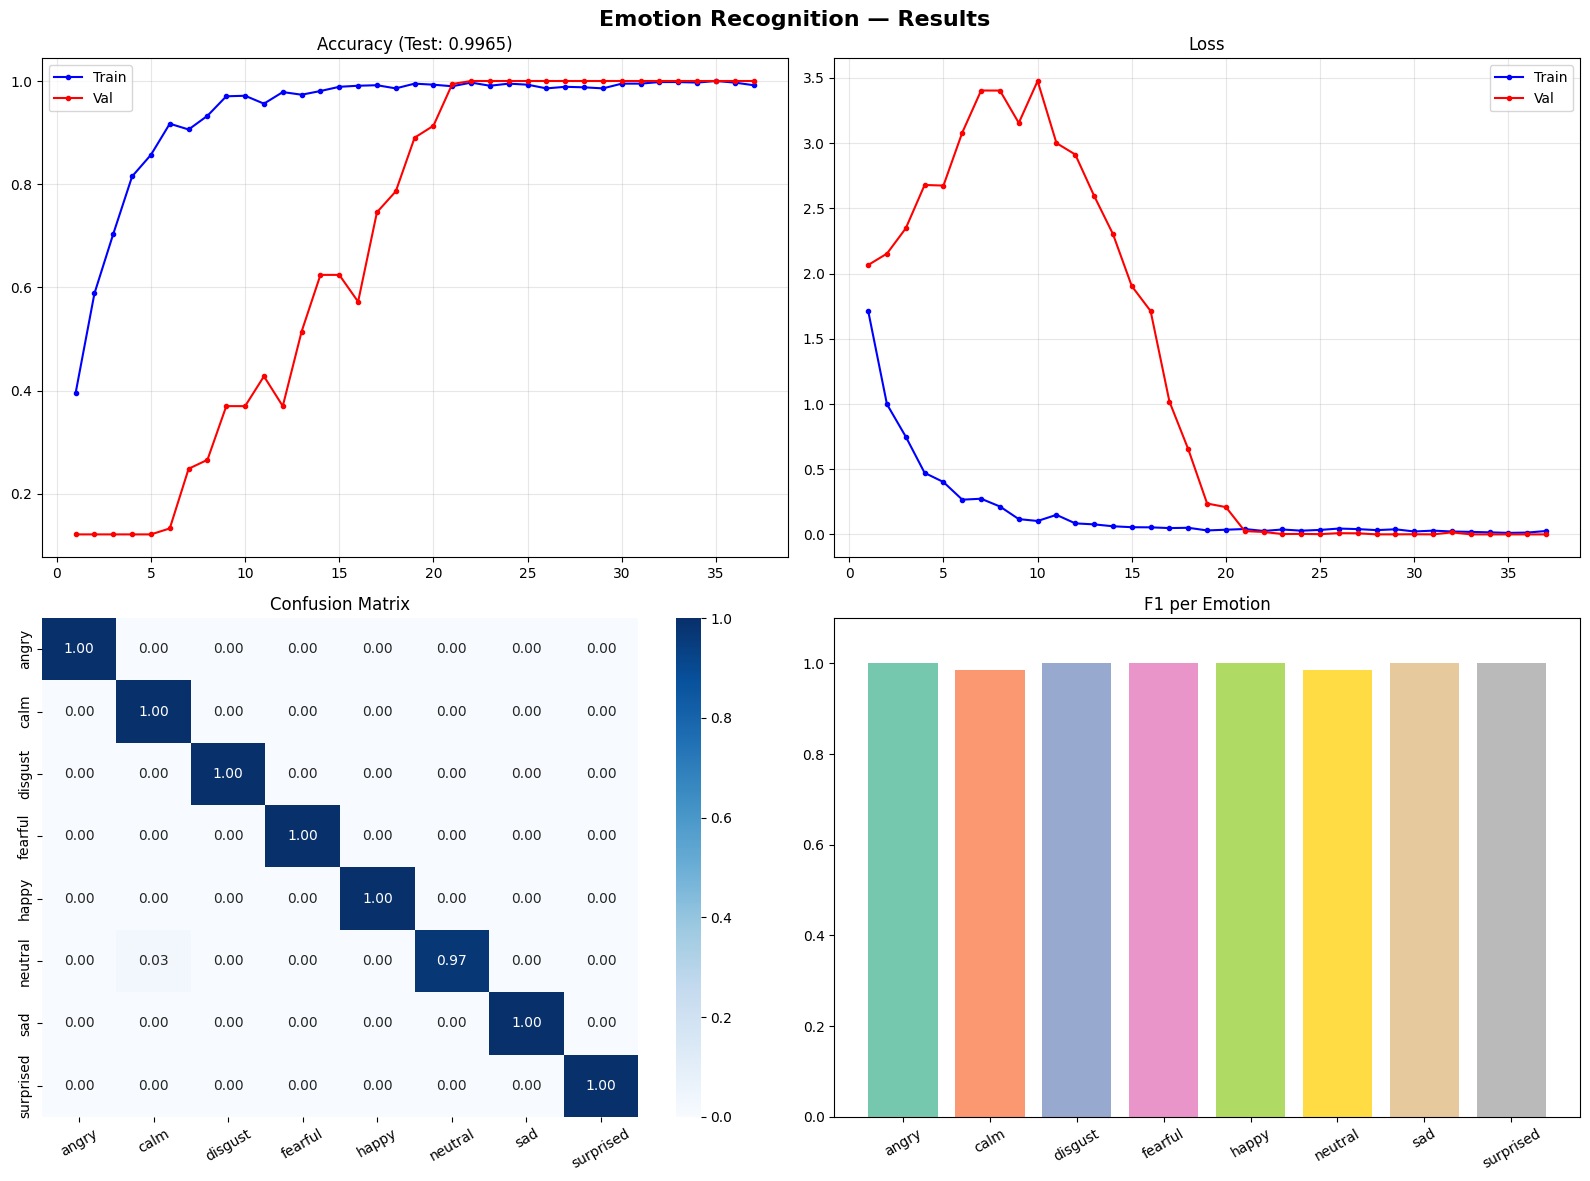


✅ Test Accuracy: 0.9965
              precision    recall  f1-score   support

       angry       1.00      1.00      1.00        36
        calm       0.97      1.00      0.99        36
     disgust       1.00      1.00      1.00        36
     fearful       1.00      1.00      1.00        36
       happy       1.00      1.00      1.00        36
     neutral       1.00      0.97      0.99        36
         sad       1.00      1.00      1.00        36
   surprised       1.00      1.00      1.00        36

    accuracy                           1.00       288
   macro avg       1.00      1.00      1.00       288
weighted avg       1.00      1.00      1.00       288



In [7]:
# ── Evaluate & Plot ───────────────────────────
loss, acc = model.evaluate(X_te, y_te, verbose=0)
y_pred = np.argmax(model.predict(X_te),axis=1)
y_true = np.argmax(y_te,axis=1)

fig, axes = plt.subplots(2,2,figsize=(16,12))
fig.suptitle('Emotion Recognition — Results', fontsize=16, fontweight='bold')

ep = range(1,len(history.history['accuracy'])+1)
axes[0,0].plot(ep,history.history['accuracy'],'b-o',ms=3,label='Train')
axes[0,0].plot(ep,history.history['val_accuracy'],'r-o',ms=3,label='Val')
axes[0,0].set_title(f'Accuracy (Test: {acc:.4f})'); axes[0,0].legend(); axes[0,0].grid(alpha=0.3)

axes[0,1].plot(ep,history.history['loss'],'b-o',ms=3,label='Train')
axes[0,1].plot(ep,history.history['val_loss'],'r-o',ms=3,label='Val')
axes[0,1].set_title('Loss'); axes[0,1].legend(); axes[0,1].grid(alpha=0.3)

cm = confusion_matrix(y_true,y_pred)
sns.heatmap(cm/cm.sum(axis=1,keepdims=True),annot=True,fmt='.2f',ax=axes[1,0],
            cmap='Blues',xticklabels=le.classes_,yticklabels=le.classes_)
axes[1,0].set_title('Confusion Matrix'); axes[1,0].tick_params(axis='x',rotation=30)

from sklearn.metrics import classification_report as cr
rep = cr(y_true,y_pred,target_names=le.classes_,output_dict=True)
f1s = {e:rep[e]['f1-score'] for e in le.classes_}
axes[1,1].bar(f1s.keys(),f1s.values(),color=plt.cm.Set2(np.linspace(0,1,n_classes)),alpha=0.9)
axes[1,1].set_title(f'F1 per Emotion'); axes[1,1].tick_params(axis='x',rotation=30)
axes[1,1].set_ylim(0,1.1)

plt.tight_layout()
plt.savefig('task2_results.png',dpi=150,bbox_inches='tight')
plt.show()
model.save('task2_model.keras')

print(f"\n✅ Test Accuracy: {acc:.4f}")
print(cr(y_true,y_pred,target_names=le.classes_))

In [8]:
# ── Download Files ────────────────────────────
from google.colab import files
files.download('task2_results.png')
files.download('task2_model.keras')
print("✅ Task 2 Complete!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Task 2 Complete!
